In [1]:
import requests
import pandas as pd
import os

In [2]:
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 4.7110,
    "longitude": -74.0721,
    "start_date": "2025-01-01",
    "end_date": "2025-12-31",
    "hourly": ",".join([
        "temperature_2m",
        "relative_humidity_2m",
        "precipitation",
        "surface_pressure",
        "wind_speed_10m",
        "shortwave_radiation"
    ]),
    "timezone": "America/Bogota"
}

response = requests.get(url, params=params)
response.raise_for_status()

datos = response.json()

print("Datos descargados correctamente")

Datos descargados correctamente


In [3]:
df = pd.DataFrame(datos["hourly"])

df.head()

,time,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,wind_speed_10m,shortwave_radiation
0,2025-01-01T00:00,10.8,99,0.0,754.6,2.7,0.0
1,2025-01-01T01:00,10.6,100,0.0,754.4,3.7,0.0
2,2025-01-01T02:00,9.8,99,0.0,753.4,3.5,0.0
3,2025-01-01T03:00,9.2,99,0.0,753.0,4.2,0.0
4,2025-01-01T04:00,8.7,98,0.0,752.6,2.6,0.0


In [4]:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 8760
Columnas: 7


In [5]:
os.makedirs("data", exist_ok=True)

df.to_csv(
    "data/datos_meteorologicos_bogota.csv",
    index=False
)

print("CSV guardado correctamente")

CSV guardado correctamente


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   time                  8760 non-null   object 
 1   temperature_2m        8760 non-null   float64
 2   relative_humidity_2m  8760 non-null   int64  
 3   precipitation         8760 non-null   float64
 4   surface_pressure      8760 non-null   float64
 5   wind_speed_10m        8760 non-null   float64
 6   shortwave_radiation   8760 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 479.2+ KB


In [7]:
df.describe()

,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,wind_speed_10m,shortwave_radiation
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,13.988847,80.829680,0.176221,756.619521,4.852146,235.203196
std,3.505813,17.608224,0.680827,1.956444,3.505932,305.271630
min,3.900000,24.000000,0.000000,750.400000,0.000000,0.000000
25%,11.200000,65.000000,0.000000,755.200000,2.300000,0.000000
50%,13.300000,88.000000,0.000000,756.500000,3.700000,4.500000
75%,17.000000,96.000000,0.100000,758.000000,6.700000,494.000000
max,23.100000,100.000000,12.100000,762.200000,20.400000,1053.000000


In [8]:
df.isnull().sum()

time                    0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
surface_pressure        0
wind_speed_10m          0
shortwave_radiation     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,wind_speed_10m,shortwave_radiation
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,13.988847,80.829680,0.176221,756.619521,4.852146,235.203196
std,3.505813,17.608224,0.680827,1.956444,3.505932,305.271630
min,3.900000,24.000000,0.000000,750.400000,0.000000,0.000000
25%,11.200000,65.000000,0.000000,755.200000,2.300000,0.000000
50%,13.300000,88.000000,0.000000,756.500000,3.700000,4.500000
75%,17.000000,96.000000,0.100000,758.000000,6.700000,494.000000
max,23.100000,100.000000,12.100000,762.200000,20.400000,1053.000000


In [11]:
df.corr(numeric_only=True)

,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,wind_speed_10m,shortwave_radiation
temperature_2m,1.000000,-0.931385,0.103252,0.618556,0.636638,0.863383
relative_humidity_2m,-0.931385,1.000000,-0.021727,-0.594481,-0.692003,-0.892140
precipitation,0.103252,-0.021727,1.000000,-0.007281,0.043490,0.051777
surface_pressure,0.618556,-0.594481,-0.007281,1.000000,0.334821,0.673547
wind_speed_10m,0.636638,-0.692003,0.043490,0.334821,1.000000,0.584025
shortwave_radiation,0.863383,-0.892140,0.051777,0.673547,0.584025,1.000000


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Librerías listas")

Librerías listas


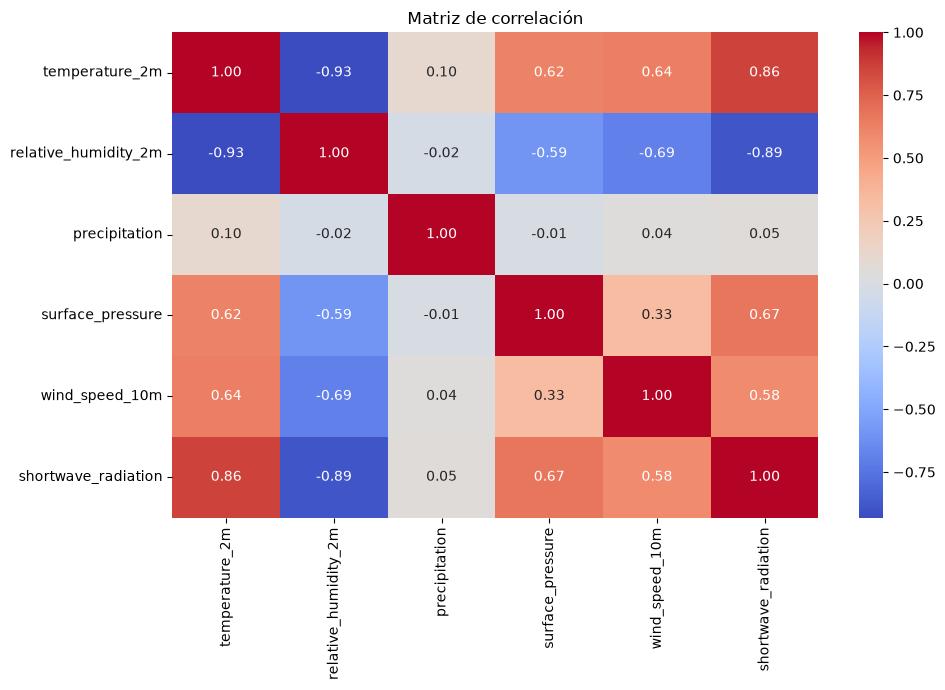

In [16]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

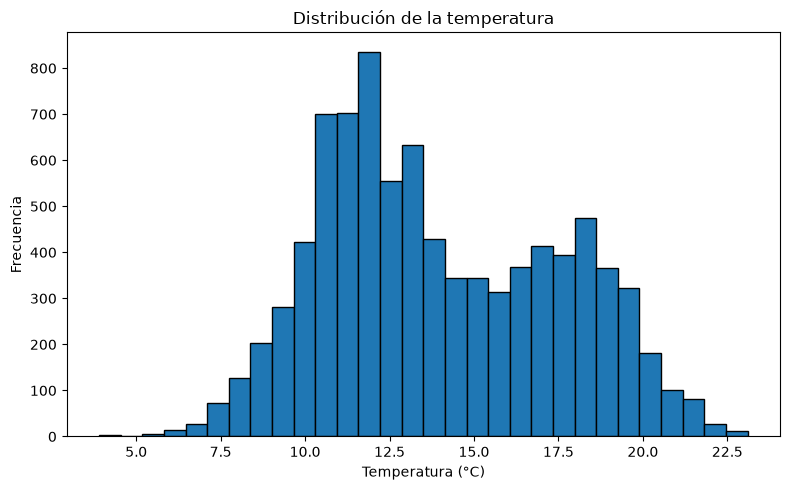

In [17]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["temperature_2m"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribución de la temperatura")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

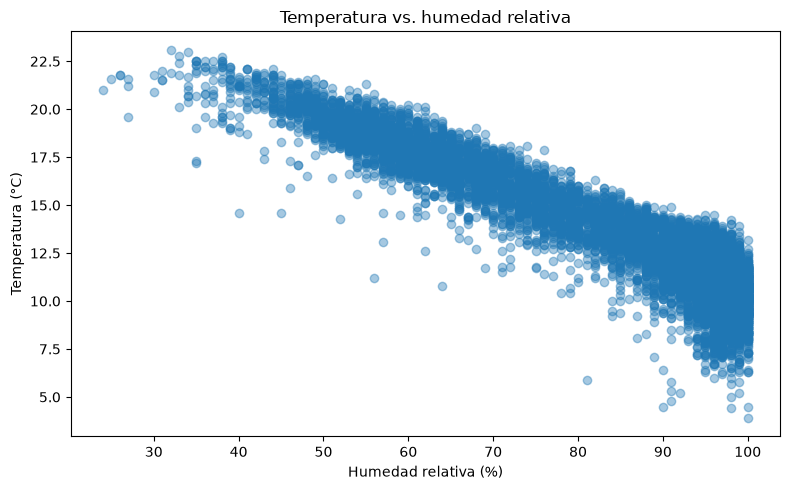

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["relative_humidity_2m"],
    df["temperature_2m"],
    alpha=0.4
)

plt.title("Temperatura vs. humedad relativa")
plt.xlabel("Humedad relativa (%)")
plt.ylabel("Temperatura (°C)")

plt.tight_layout()
plt.show()

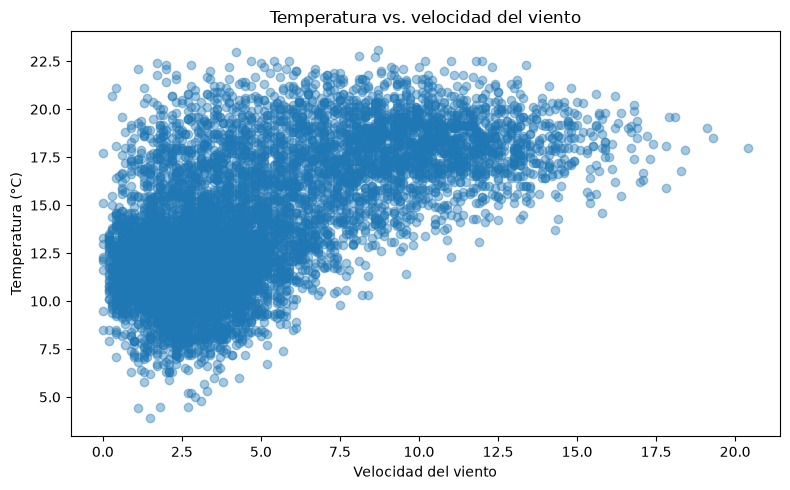

In [19]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["wind_speed_10m"],
    df["temperature_2m"],
    alpha=0.4
)

plt.title("Temperatura vs. velocidad del viento")
plt.xlabel("Velocidad del viento")
plt.ylabel("Temperatura (°C)")

plt.tight_layout()
plt.show()

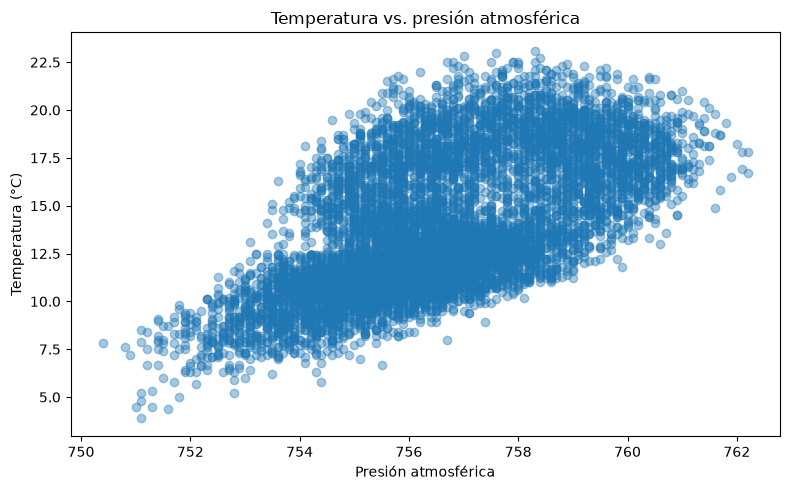

In [20]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["surface_pressure"],
    df["temperature_2m"],
    alpha=0.4
)

plt.title("Temperatura vs. presión atmosférica")
plt.xlabel("Presión atmosférica")
plt.ylabel("Temperatura (°C)")

plt.tight_layout()
plt.show()

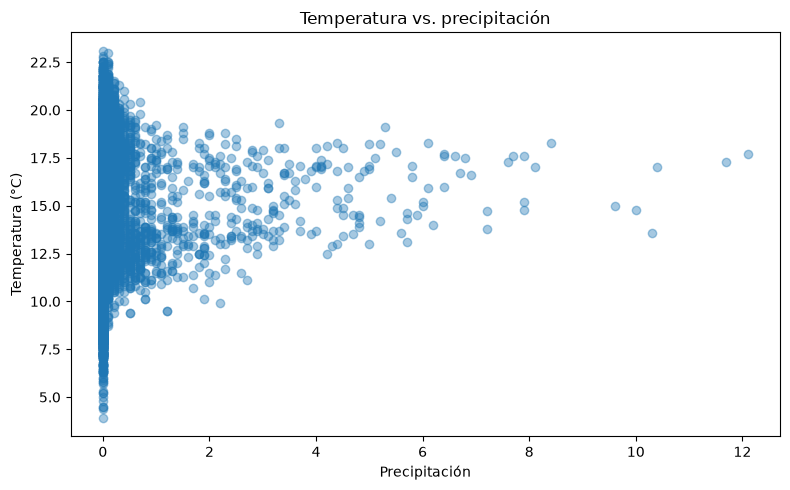

In [21]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["precipitation"],
    df["temperature_2m"],
    alpha=0.4
)

plt.title("Temperatura vs. precipitación")
plt.xlabel("Precipitación")
plt.ylabel("Temperatura (°C)")

plt.tight_layout()
plt.show()

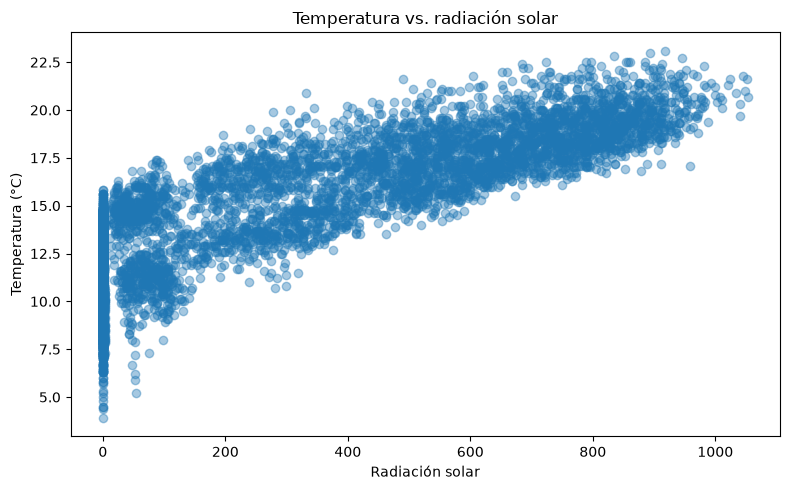

In [22]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["shortwave_radiation"],
    df["temperature_2m"],
    alpha=0.4
)

plt.title("Temperatura vs. radiación solar")
plt.xlabel("Radiación solar")
plt.ylabel("Temperatura (°C)")

plt.tight_layout()
plt.show()

In [23]:
df.describe()

,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,wind_speed_10m,shortwave_radiation
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,13.988847,80.829680,0.176221,756.619521,4.852146,235.203196
std,3.505813,17.608224,0.680827,1.956444,3.505932,305.271630
min,3.900000,24.000000,0.000000,750.400000,0.000000,0.000000
25%,11.200000,65.000000,0.000000,755.200000,2.300000,0.000000
50%,13.300000,88.000000,0.000000,756.500000,3.700000,4.500000
75%,17.000000,96.000000,0.100000,758.000000,6.700000,494.000000
max,23.100000,100.000000,12.100000,762.200000,20.400000,1053.000000


In [24]:
# Variables del modelo

X = df[
    [
        "relative_humidity_2m",
        "precipitation",
        "surface_pressure",
        "wind_speed_10m",
        "shortwave_radiation"
    ]
]

y = df["temperature_2m"]

print("Variables predictoras:", X.columns.tolist())
print("Variable objetivo:", y.name)

Variables predictoras: ['relative_humidity_2m', 'precipitation', 'surface_pressure', 'wind_speed_10m', 'shortwave_radiation']
Variable objetivo: temperature_2m


In [25]:
df = df.sort_values("time").reset_index(drop=True)

In [26]:
# Separación temporal 80/20

corte = int(len(df) * 0.80)

X = df[
    [
        "relative_humidity_2m",
        "precipitation",
        "surface_pressure",
        "wind_speed_10m",
        "shortwave_radiation"
    ]
]

y = df["temperature_2m"]

X_train = X.iloc[:corte]
X_test = X.iloc[corte:]

y_train = y.iloc[:corte]
y_test = y.iloc[corte:]

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (7008, 5)
Datos de prueba: (1752, 5)


In [29]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(X_train, y_train)

predicciones = modelo.predict(X_test)

In [30]:
coeficientes = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": modelo.coef_
})

coeficientes

,Variable,Coeficiente
0,relative_humidity_2m,-0.157202
1,precipitation,0.440563
2,surface_pressure,0.165470
3,wind_speed_10m,-0.003170
4,shortwave_radiation,0.001152


In [31]:
print("Intercepto:", modelo.intercept_)

Intercepto: -98.91108537354027


In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, predicciones)
mse = mean_squared_error(y_test, predicciones)
rmse = mse ** 0.5
r2 = r2_score(y_test, predicciones)

print("MAE :", round(mae, 4))
print("MSE :", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

MAE : 0.8977
MSE : 1.2668
RMSE: 1.1255
R²  : 0.9015


In [33]:
comparacion = pd.DataFrame({
    "Real": y_test.values,
    "Predicha": predicciones
})

comparacion.head(10)

,Real,Predicha
0,11.1,11.767247
1,9.7,11.029303
2,9.7,10.826263
3,9.9,10.839640
4,10.4,11.219282
5,10.4,11.267338
6,10.0,11.152076
7,11.9,13.305994
8,14.5,16.195105
9,16.2,17.392632


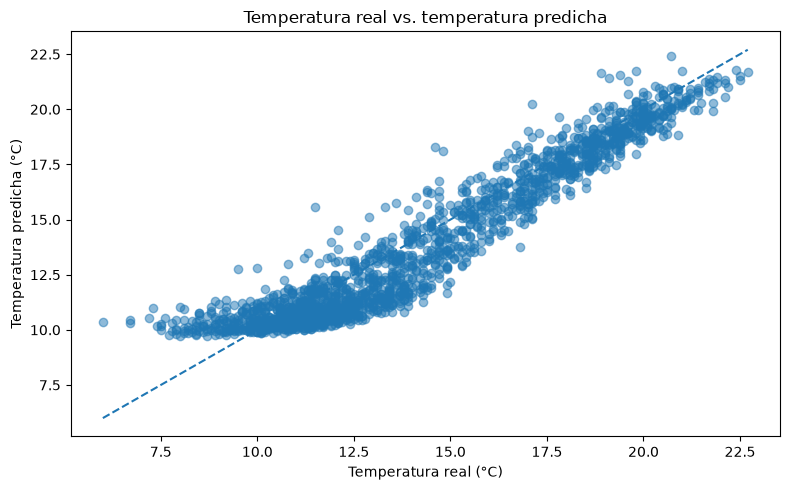

In [34]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, predicciones, alpha=0.5)

minimo = min(y_test.min(), predicciones.min())
maximo = max(y_test.max(), predicciones.max())

plt.plot([minimo, maximo], [minimo, maximo], linestyle="--")

plt.title("Temperatura real vs. temperatura predicha")
plt.xlabel("Temperatura real (°C)")
plt.ylabel("Temperatura predicha (°C)")

plt.tight_layout()
plt.show()

In [35]:
residuos = y_test - predicciones

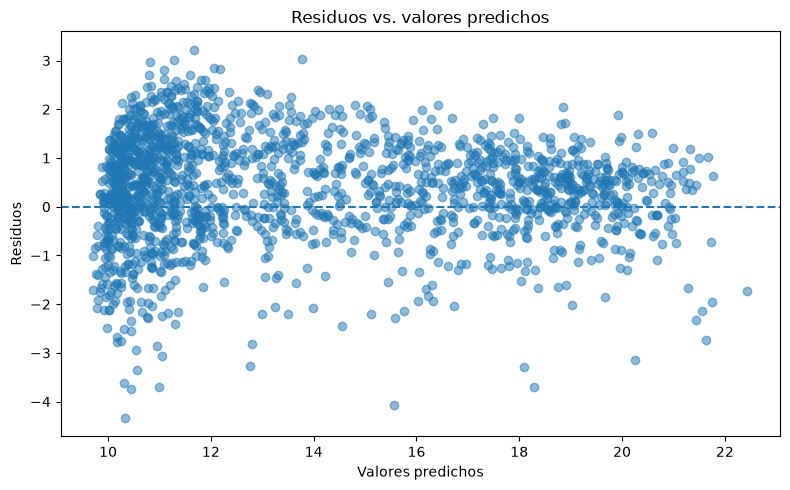

In [36]:
plt.figure(figsize=(8, 5))

plt.scatter(predicciones, residuos, alpha=0.5)
plt.axhline(0, linestyle="--")

plt.title("Residuos vs. valores predichos")
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")

plt.tight_layout()
plt.show()

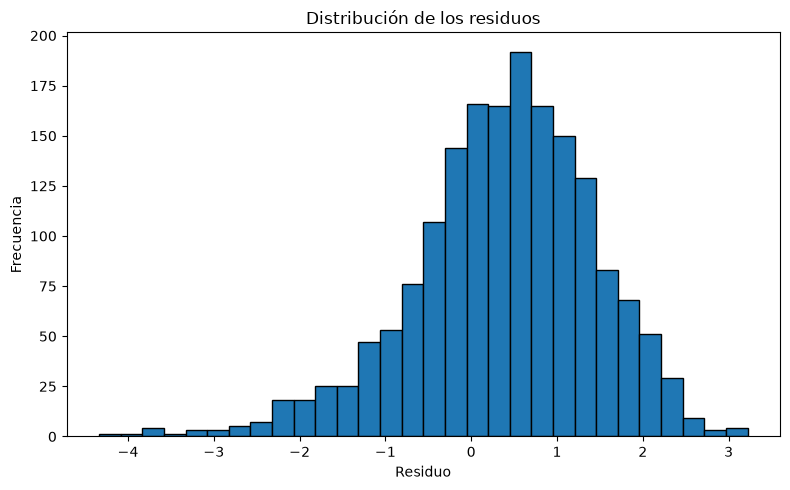

In [37]:
plt.figure(figsize=(8, 5))

plt.hist(residuos, bins=30, edgecolor="black")

plt.title("Distribución de los residuos")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

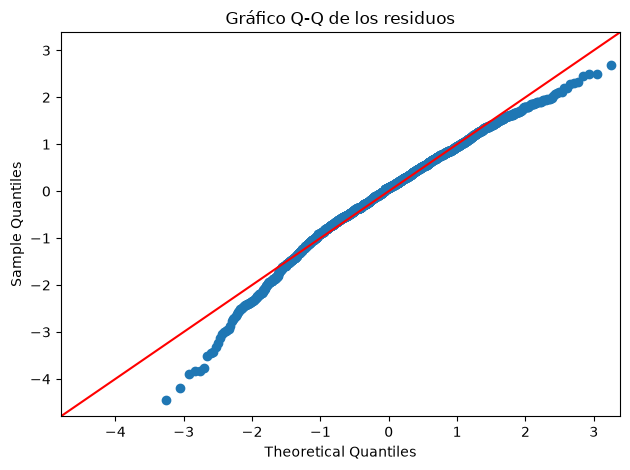

In [39]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

sm.qqplot(residuos, line="45", fit=True)

plt.title("Gráfico Q-Q de los residuos")
plt.tight_layout()
plt.show()

In [40]:
from statsmodels.stats.diagnostic import het_breuschpagan

X_test_const = sm.add_constant(X_test)

resultado_bp = het_breuschpagan(
    residuos,
    X_test_const
)

labels = [
    "LM Statistic",
    "LM-Test p-value",
    "F-Statistic",
    "F-Test p-value"
]

dict(zip(labels, resultado_bp))

{'LM Statistic': np.float64(103.00546349696565),
 'LM-Test p-value': np.float64(1.2284094926612005e-20),
 'F-Statistic': np.float64(21.812993952920976),
 'F-Test p-value': np.float64(3.0324128756681697e-21)}

In [41]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(X)

vif = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif

,Variable,VIF
0,const,1.000000
1,relative_humidity_2m,6.295862
2,precipitation,1.010815
3,surface_pressure,1.855004
4,wind_speed_10m,1.962219
5,shortwave_radiation,5.867569


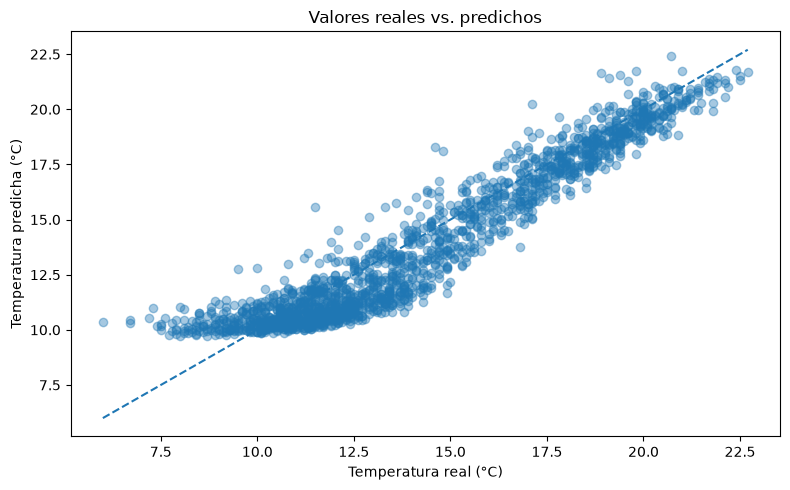

In [42]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, predicciones, alpha=0.4)

minimo = min(y_test.min(), predicciones.min())
maximo = max(y_test.max(), predicciones.max())

plt.plot(
    [minimo, maximo],
    [minimo, maximo],
    linestyle="--"
)

plt.title("Valores reales vs. predichos")
plt.xlabel("Temperatura real (°C)")
plt.ylabel("Temperatura predicha (°C)")

plt.tight_layout()
plt.show()